**Mount Drive (Colab)**

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


**Dataset Loading and Inspection**

In [2]:
import pandas as pd
loan_data = pd.read_csv('drive/MyDrive/Datasets For ML/Loan Prediction Problem Dataset.csv')

print("Shape:", loan_data.shape)
print("Duplicated:", loan_data.duplicated().sum())
print("Null Values:\n", loan_data.isnull().sum())
print("\nFirst 2 Rows:\n", loan_data.head(2))

Shape: (614, 13)
Duplicated: 0
Null Values:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

First 2 Rows:
     Loan_ID Gender Married Dependents Education Self_Employed  \
0  LP001002   Male      No          0  Graduate            No   
1  LP001003   Male     Yes          1  Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  


**Drop Unnecessary Columns:** Drop Loan_ID (not useful)

In [3]:
loan_data.drop("Loan_ID", axis=1, inplace=True)

**Handle Missing Values**

Categorical → fill with mode

Numerical → fill with median

In [4]:
cat_cols = ["Gender", "Married", "Dependents", "Self_Employed"]
for col in cat_cols:
    loan_data[col] = loan_data[col].fillna(loan_data[col].mode()[0])

In [5]:
num_cols = ["LoanAmount", "Loan_Amount_Term", "Credit_History"]
for col in num_cols:
  loan_data[col] = loan_data[col].fillna(loan_data[col].median())

In [6]:
print("Remaining Null Values:\n", loan_data.isnull().sum())

Remaining Null Values:
 Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


**Encode Categorical Variables**

In [7]:
loan_data = pd.get_dummies(loan_data, drop_first=True)

# Convert Target (Loan_Status_Y as 1, else 0)
loan_data["Loan_Status_Y"] = loan_data["Loan_Status_Y"].astype(int)

X = loan_data.drop("Loan_Status_Y", axis=1)
y = loan_data["Loan_Status_Y"]

**Train-Test Split**

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (491, 14)
Test Shape: (123, 14)


**Build AdaBoost with Decision Stumps (Weak Learners)**

Weak learners = DecisionTreeClassifier(max_depth=1)

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

base_stump = DecisionTreeClassifier(max_depth=1, random_state=42)

ada_model = AdaBoostClassifier(
    estimator=base_stump,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

ada_model.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   random_state=42)

**Model Evaluation**

In [10]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = ada_model.predict(X_test)

print("Training Accuracy:", accuracy_score(y_train, ada_model.predict(X_train)))
print("Testing Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Training Accuracy: 0.8085539714867617
Testing Accuracy: 0.8536585365853658

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.58      0.71        38
           1       0.84      0.98      0.90        85

    accuracy                           0.85       123
   macro avg       0.88      0.78      0.81       123
weighted avg       0.86      0.85      0.84       123



**Weak Learners (Decision Stumps)**

Each weak learner is a small decision tree:

In [11]:
print("Number of Weak Learners:", len(ada_model.estimators_))

Number of Weak Learners: 50


View first 3 weak learners:

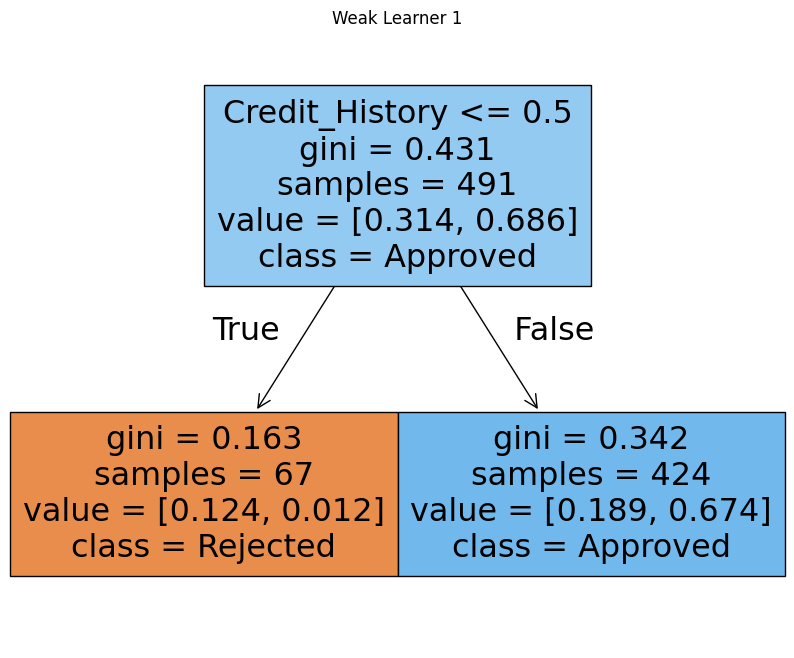

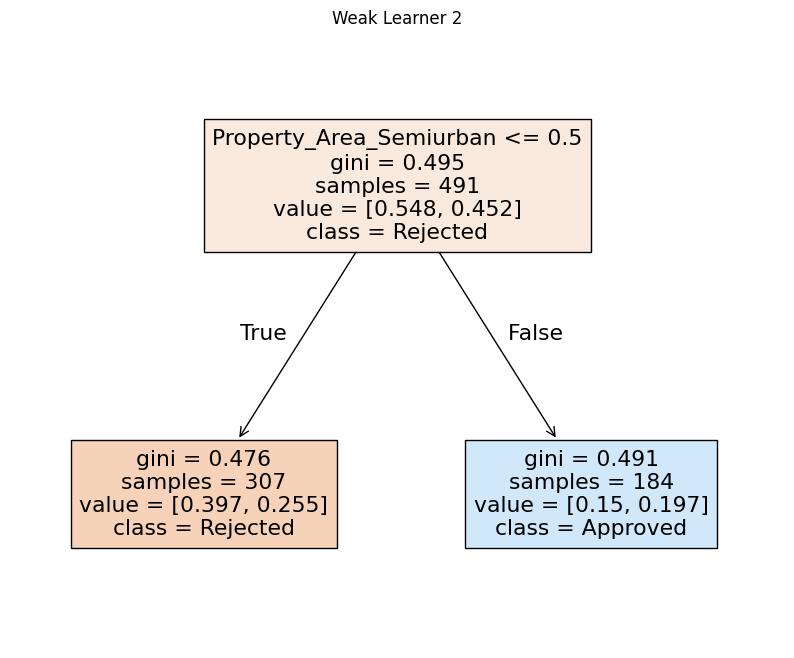

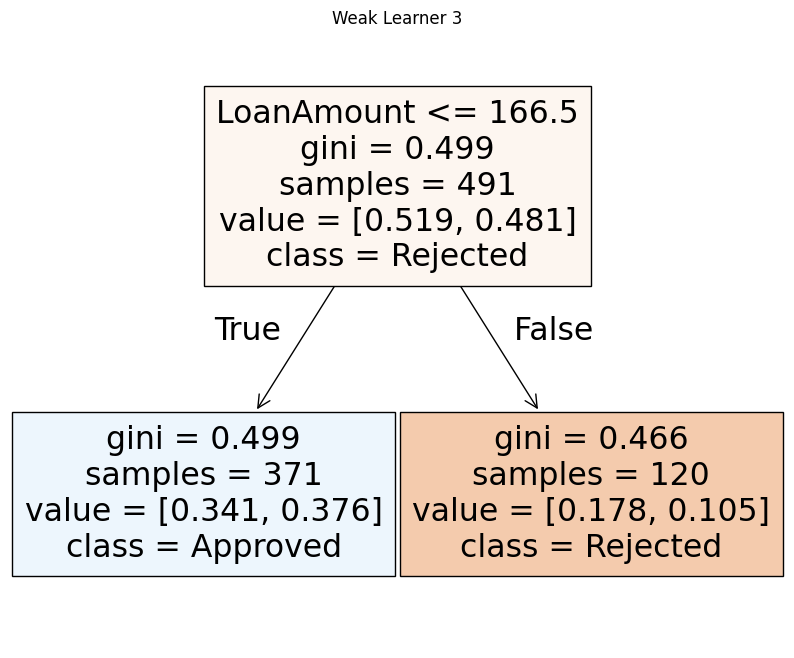

In [12]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

for i in range(3):
    plt.figure(figsize=(10, 8))
    plot_tree(
        ada_model.estimators_[i],
        feature_names=X.columns,
        class_names=["Rejected", "Approved"],
        filled=True
    )
    plt.title(f"Weak Learner {i+1}")
    plt.show()

**Learner Weights (Alpha Values)**

In AdaBoost: 𝛼 𝑡 = 1 / 2 ln((1 - error t)/error t)

In sklearn, alpha values are stored in:

In [13]:
alpha_values = ada_model.estimator_weights_

print("Alpha Values (First 10):")
print(alpha_values[:10])

Alpha Values (First 10):
[1.37614199 0.38282902 0.21776012 0.17441972 0.16937652 0.23057599
 0.19139737 0.17812995 0.29095193 0.06868799]


**Final Strong Model Equation**

AdaBoost final prediction: F(x)=
t=1
∑
T α
t h
t (x)

Where:

ℎ
𝑡
(
𝑥
) = weak learner prediction

α
t = learner weight

T = number of estimators

Higher alpha → more influence on final decision.

**Visualize Alpha Values**

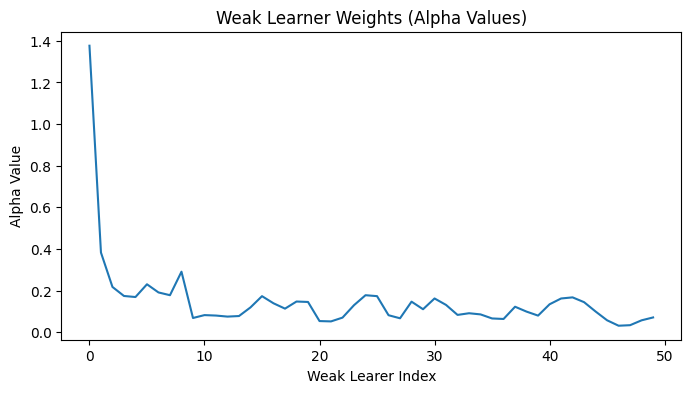

In [15]:
plt.figure(figsize=(8,4))
plt.plot(alpha_values)
plt.title("Weak Learner Weights (Alpha Values)")
plt.xlabel("Weak Learer Index")
plt.ylabel("Alpha Value")
plt.show()

**Conclusion**

The AdaBoost model was implemented for the loan prediction dataset using decision stumps as weak learners. After preprocessing, handling missing values, and encoding categorical features, the model was trained and evaluated on training and testing data. The results show that AdaBoost effectively improves classification performance by combining multiple weak learners and assigning higher importance to more accurate learners, resulting in a strong predictive model for loan approval classification.
